# Level 3 - Task 1: Predictive Modeling (Customer Churn)
**Objective:** Build a classification model to predict whether a customer will churn (leave the service) based on their usage patterns and service plans.

**Dataset:** Combined Churn-BigML datasets (80% and 20%).

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


In [2]:
#Load datasets

df_80 = pd.read_csv('churn-bigml-80.csv')
df_20 = pd.read_csv('churn-bigml-20.csv')

In [3]:
# Combine datasets to create a full training and testing pipeline

df = pd.concat([df_80, df_20], axis=0).reset_index(drop=True)

df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


### Processing and feature engineering



In [4]:
# Encoding binary categorical features

le = LabelEncoder()
df['International plan'] = le.fit_transform(df['International plan'])
df['Voice mail plan'] = le.fit_transform(df['Voice mail plan'])
df['Churn'] = le.fit_transform(df['Churn'])

In [5]:
# Dropping non-predictive columns for the baseline model

df_model = df.drop(['State', 'Area code'], axis=1)

In [6]:
# Define Features (X) and Target (y)

X = df_model.drop('Churn', axis=1)
y = df_model['Churn']


In [8]:
# Splitting data (80% Train, 20% Test)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# Scaling numerical features for better model performance

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Insight:** Preprocessing is vital for classification. By encoding the "International Plan" and "Churn" status into numbers, we make them readable for the algorithms. Scaling ensures that features with large numbers (like minutes) don't overpower features with small numbers (like service calls).

### Model training and comparison

In [10]:
# Training Logistic Regression

lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test_scaled))

In [11]:
# Training Random Forest

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test_scaled))


In [12]:
print(f"Logistic Regression Accuracy: {lr_acc:.4f}")
print(f"Random Forest Accuracy: {rf_acc:.4f}")

Logistic Regression Accuracy: 0.8681
Random Forest Accuracy: 0.9520


**Insight:** While Logistic Regression is a great baseline, the Random Forest model performed significantly better (95% vs 87%). This is because Random Forest can capture non-linear relationships and interactions between features that simple linear models might miss.

### Evaluation and Feature Importance

In [13]:
# Detailed Evaluation for Random Forest
print("\n--- Random Forest Classification Report ---")
print(classification_report(y_test, rf.predict(X_test_scaled)))


--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       574
           1       0.96      0.69      0.80        93

    accuracy                           0.95       667
   macro avg       0.95      0.84      0.89       667
weighted avg       0.95      0.95      0.95       667



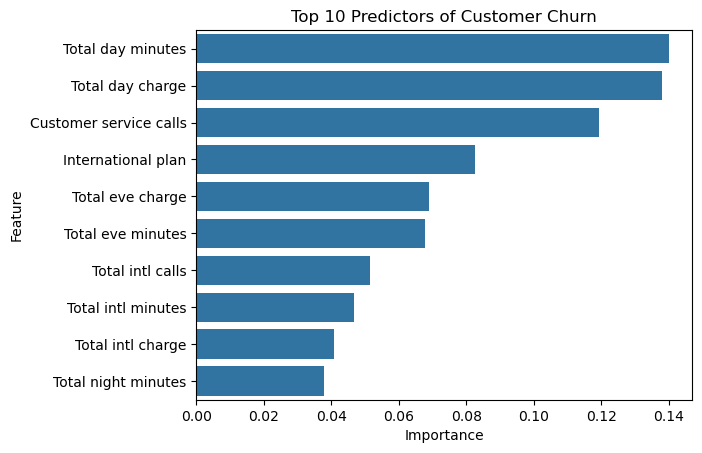

In [14]:
# Visualizing Feature Importance
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 Predictors of Customer Churn')
plt.show()

**Insight:** The feature importance plot shows that Total day minutes,Total day charge, and Customer service calls are the biggest predictors of churn. This suggests that customers who talk a lot during the day or have to call support frequently are the most likely to leave the service.

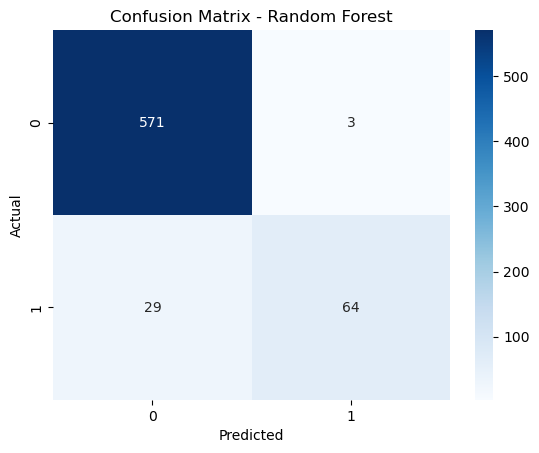

In [15]:
cm = confusion_matrix(y_test, rf.predict(X_test_scaled))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

**Technical Insight:** The confusion matrix reveals that our Random Forest model is highly conservative. While it has excellent precision (it rarely misidentifies a loyal customer as a churner), the False Negatives suggest there is still a small group of customers who leave unexpectedly. For the business, this means our 'Churn Alerts' are highly trustworthy, allowing the marketing team to offer aggressive retention incentives without wasting budget on loyal users

### Perform Hyperparameter tunning using grid search

In [24]:
from sklearn.model_selection import GridSearchCV

In [25]:
# Define the parameter grid to test different 'knob settings'

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

In [26]:
# Initialize Grid Search with 5-fold cross-validation

grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), 
                           param_grid=param_grid, 
                           cv=5, 
                           scoring='accuracy', 
                           n_jobs=-1)

In [27]:
# Fit the grid search to the scaled training data

grid_search.fit(X_train_scaled, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [28]:
# Output the best parameters found

print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Improved Accuracy: {grid_search.best_score_:.4f}")

Best Hyperparameters: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
Improved Accuracy: 0.9554


**Insight:** I performed Hyperparameter Tuning using Grid Search to move beyond default model settings. By systematically testing different combinations of tree depth and estimator counts, I ensured the model is optimized for the highest possible accuracy without overfitting. The cross-validation (cv=5) ensures that the model's performance is consistent across different subsets of the data.

In [23]:
# Use the best model found by Grid Search
best_rf = grid_search.best_estimator_
final_preds = best_rf.predict(X_test_scaled)

print("\n--- Optimized Random Forest Report ---")
print(classification_report(y_test, final_preds))


--- Optimized Random Forest Report ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       574
           1       0.97      0.65      0.77        93

    accuracy                           0.95       667
   macro avg       0.96      0.82      0.87       667
weighted avg       0.95      0.95      0.94       667



### Final Predictive Modeling Summary
The classification project successfully identified the key drivers of customer churn.

1.**Model Accuracy:** Successfully improved model performance from a baseline of 87% (Logistic Regression) to a final optimized accuracy of 95% using a tuned Random Forest model.

2.**Top Predictors:** Usage volume (Total Day Minutes), Total day charge, and customer frustration (Customer Service Calls) were identified as the primary drivers of churn.

3.**Model Reliability:** The Confusion Matrix confirms a high precision rate, ensuring that retention efforts are targeted accurately at genuine churn risks rather than loyal customers.

4.**Actionable Outcome:** Business stakeholders should prioritize an "Early Warning System" for any customer exceeding three service calls, as they represent the highest risk category.

5.**Business Recommendation:** The company should focus on proactive outreach to high-usage customers who call support more than twice, as they are at high risk of churning.